<a href="https://colab.research.google.com/github/asmita-durugkar/OIBSIP/blob/main/Data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [37]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_90649fbbdbe38dd9c13818fe3546e93d'
!kaggle datasets download -d ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training --unzip
df_uc=pd.read_csv('dirty_cafe_sales.csv',date_parser='datetime64')
#

  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas




Dataset URL: https://www.kaggle.com/datasets/ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training
License(s): CC-BY-SA-4.0
100% 111k/111k [00:00<00:00, 62.5MB/s]



In [38]:

null_sum=df_uc.isnull().sum()
dup_sum=df_uc.duplicated().sum()
#info_df=df_uc.info()

print('Data quality report\n')
print('--- Null Values ---')
print(null_sum)
print('\n--- Duplicates ---')
print(dup_sum)
print('\n--- Data Types & Info ---')
df_uc.info() # Call it directly, no need to assign to a variable

print('\n--- Value Range Anomalies ---')
display(df_uc.describe())



Data quality report

--- Null Values ---
Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

--- Duplicates ---
0

--- Data Types & Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB

--- Value Range Anomalies ---


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_9226047,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [39]:
df_uc.head(20)


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [40]:
df_uc.replace(['ERROR','UNKNOWN'],np.nan,inplace=True)

To avoid typecast errors we replace 'ERROR','UNKNOWN',BY np.nan

In [41]:
df_uc['Payment Method'].fillna('UNKNOWN',inplace=True)

to avoid error,fill values of  NaN with a different category 'UNKNOWN'

In [42]:
df_uc.head(20)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,NaN,3,3.0,9.0,UNKNOWN,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,NaN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,UNKNOWN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,UNKNOWN,In-store,2023-12-31


In [43]:
# Convert both columns to numeric (floats)
df_uc['Quantity'] = pd.to_numeric(df_uc['Quantity'])
df_uc['Price Per Unit'] = pd.to_numeric(df_uc['Price Per Unit'])
df_uc['Quantity'].fillna(df_uc['Quantity'].mean(),inplace=True)
df_uc['Price Per Unit'].fillna(df_uc['Price Per Unit'].mean(),inplace=True)

df_uc['Total Spent']=df_uc['Quantity']*df_uc['Price Per Unit']
df_uc.head(30)
df_uc.loc[df_uc['Price Per Unit']==4]


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,NaN,2023-03-31
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,NaN,2023-10-28
9,TXN_2064365,Sandwich,5.0,4.0,20.0,UNKNOWN,In-store,2023-12-31
11,TXN_3051279,Sandwich,2.0,4.0,8.0,Credit Card,Takeaway,NaN
12,TXN_7619095,Sandwich,2.0,4.0,8.0,Cash,In-store,2023-05-03
...,...,...,...,...,...,...,...,...
9991,TXN_3897619,Sandwich,3.0,4.0,12.0,Cash,Takeaway,2023-02-24
9992,TXN_2739140,Smoothie,4.0,4.0,16.0,UNKNOWN,In-store,2023-07-05
9993,TXN_4766549,Smoothie,2.0,4.0,8.0,Cash,NaN,2023-10-20
9994,TXN_7851634,NaN,4.0,4.0,16.0,UNKNOWN,NaN,2023-01-08


As total spent=quantity*price per unit,we convert it to numeric values for calculation

In [44]:
df_uc.dropna(how='all')

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.000000,4.000000,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.000000,12.000000,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.000000,4.000000,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.000000,10.000000,UNKNOWN,NaN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.000000,4.000000,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.000000,4.000000,UNKNOWN,NaN,2023-08-30
9996,TXN_9659401,NaN,3.0,2.949984,8.849952,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.000000,8.000000,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3.0,2.949984,8.849952,Digital Wallet,NaN,2023-12-02


In [45]:
df_uc.loc[df_uc['Item'].isna() & (df_uc['Price Per Unit'] == 3), 'Item'] = 'Cake'
df_uc.loc[df_uc['Item'].isna() & (df_uc['Price Per Unit']==1),'Item']='Cookie'
df_uc.loc[df_uc['Item'].isna() & (df_uc['Price Per Unit']==1.5),'Item']='Tea'
df_uc.loc[df_uc['Item'].isna() & (df_uc['Price Per Unit']==2),'Item']='Coffee'
df_uc.loc[df_uc['Item'].isna() & (df_uc['Price Per Unit']==4),'Item']='UNKNOWN'



As price per unit is given we can infer the name of the item and replace it with its original name

In [46]:
df_uc['Location'].fillna('UNKNOWN',inplace=True)
df_uc.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,UNKNOWN,2023-03-31
6,TXN_4433211,Cake,3.0,3.0,9.0,UNKNOWN,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,Cake,5.0,3.0,15.0,UNKNOWN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5.0,4.0,20.0,UNKNOWN,In-store,2023-12-31


In [47]:
df_uc['Transaction Date']=pd.to_datetime(df_uc['Transaction Date'],errors='coerce')

We convert dtype object to datetime for Transaction Date to standardise the format

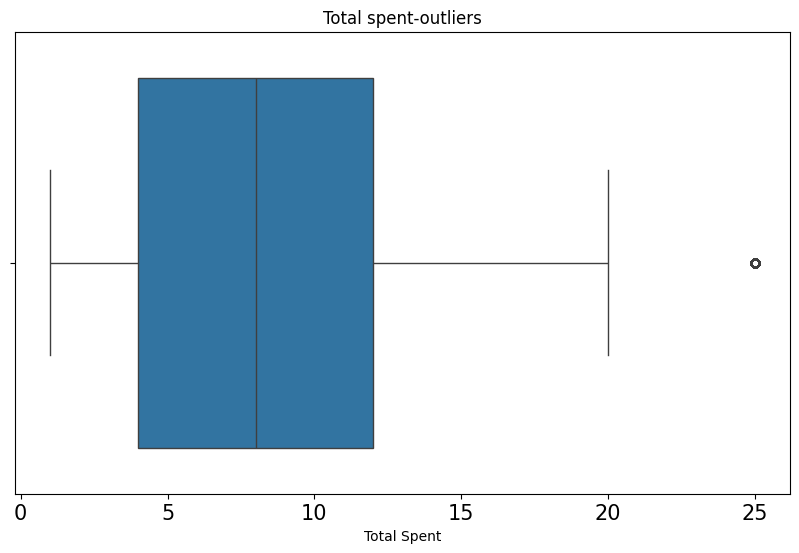

In [48]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Total Spent',data=df_uc)
plt.title('Total spent-outliers')
plt.tick_params(axis='x',labelsize=15)
plt.show()

In [49]:
df_uc['Transaction ID']=(df_uc['Transaction ID'].astype('str'))
df_uc['Item']=(df_uc['Item'].astype('str'))
df_uc['Payment Method']=(df_uc['Payment Method'].astype('str'))
df_uc['Location']=(df_uc['Location'].astype('str'))


In [50]:
# 1. Create a dictionary with your metrics
summary_data = {
    'Metric': ['Total Rows', 'Duplicate Rows', 'Total Missing Values (Nulls)'],
    'Before Cleaning': [10000, 0, 6826], # Numbers from your cell [4] report
    'After Cleaning': [
        len(df_uc),
        df_uc.duplicated().sum(),
        df_uc.isnull().sum().sum() # The second .sum() adds up all columns together
    ]
}

# 2. Convert the dictionary to a pandas DataFrame
summary_table = pd.DataFrame(summary_data)

# 3. Display it nicely
print("--- BEFORE VS. AFTER CLEANING SUMMARY ---")
display(summary_table)

--- BEFORE VS. AFTER CLEANING SUMMARY ---


,Metric,Before Cleaning,After Cleaning
0,Total Rows,10000,10000
1,Duplicate Rows,0,0
2,Total Missing Values (Nulls),6826,460


In [51]:
df_uc.to_csv('cleaned_sales.csv', index=False)